# PCD_Assignment02
## Image Enhancement Using OpenCV

**Nama:** Chelsea Christofera Antonioli Purnomo  
**NIM:** 25/558145/PA/23462  
**Kelas:** KOM B  
**Mata Kuliah:** Pengolahan Citra Digital  
**Tugas:** Peningkatan Kualitas Citra (Image Enhancement)  


## 1. Pendahuluan

Peningkatan kualitas citra (*image enhancement*) merupakan proses penting dalam pengolahan citra digital yang bertujuan untuk memperbaiki kualitas visual dan kemampuan interpretasi suatu citra.

Degradasi citra dapat terjadi karena pencahayaan yang kurang memadai, pencahayaan berlebih, kontras yang terbatas, pergerakan kamera, defokus, serta kondisi akuisisi lainnya.

Dalam tugas ini, empat citra dengan karakteristik degradasi yang berbeda diproses menggunakan OpenCV. Teknik-teknik yang dipilih meliputi koreksi gamma, peregangan kontras (*contrast stretching*), *Contrast Limited Adaptive Histogram Equalization* (CLAHE), dan *unsharp masking*.

Hasil peningkatan kualitas dievaluasi baik secara visual maupun kuantitatif. Beberapa statistik citra—seperti intensitas rata-rata, standar deviasi, entropi, persentase piksel gelap, persentase piksel terang, dan varians Laplacian—dihitung sebelum dan sesudah proses peningkatan kualitas.

## 2. Tujuan

Tujuan dari tugas ini adalah:

1. Menerapkan teknik peningkatan kualitas citra yang tepat menggunakan Python dan OpenCV.
3. Memahami bagaimana koreksi gamma memengaruhi kecerahan citra.
4. Meningkatkan kontras lokal menggunakan CLAHE.
5. Meningkatkan kontras global menggunakan *contrast stretching*.
6. Meningkatkan ketajaman visual menggunakan *unsharp masking*.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path

print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)

OpenCV version: 5.0.0
NumPy version: 2.1.3


## 3. Persiapan Dataset

Dataset ini terdiri dari empat citra yang merepresentasikan berbagai kondisi degradasi citra.

Citra-citra tersebut adalah:

- `image1_underexposed.jpeg`
- `image2_low_contrast.jpeg`
- `image3_blurred.jpeg`
- `image4_overexposed.jpeg`

Citra-citra tersebut digunakan sebagai data masukan untuk eksperimen peningkatan kualitas citra.

In [35]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print("-", filename)

Uploaded files:


In [37]:
image_paths = {
    "Underexposed": "image1_underexposed.jpeg",
    "Low Contrast": "image2_low_contrast.jpeg",
    "Blurred": "image3_blurred.jpeg",
    "Overexposed": "image4_overexposed.jpeg"
}

images = {}

for name, path in image_paths.items():
    image = cv2.imread(path)

    if image is None:
        raise FileNotFoundError(f"Could not load image: {path}")

    # OpenCV reads images as BGR.
    # That's why we need to convert BGR to RGB for correct visualization with Matplotlib.
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    images[name] = image

print("All images loaded successfully.")

for name, image in images.items():
    print(f"{name}: {image.shape}")

All images loaded successfully.
Underexposed: (1599, 1040, 3)
Low Contrast: (1280, 720, 3)
Blurred: (1600, 900, 3)
Overexposed: (1280, 720, 3)


## 4. Visualisasi Citra Asli

Sebelum dilakukan peningkatan kualitas, semua citra masukan divisualisasikan untuk mengidentifikasi karakteristik degradasi utamanya.

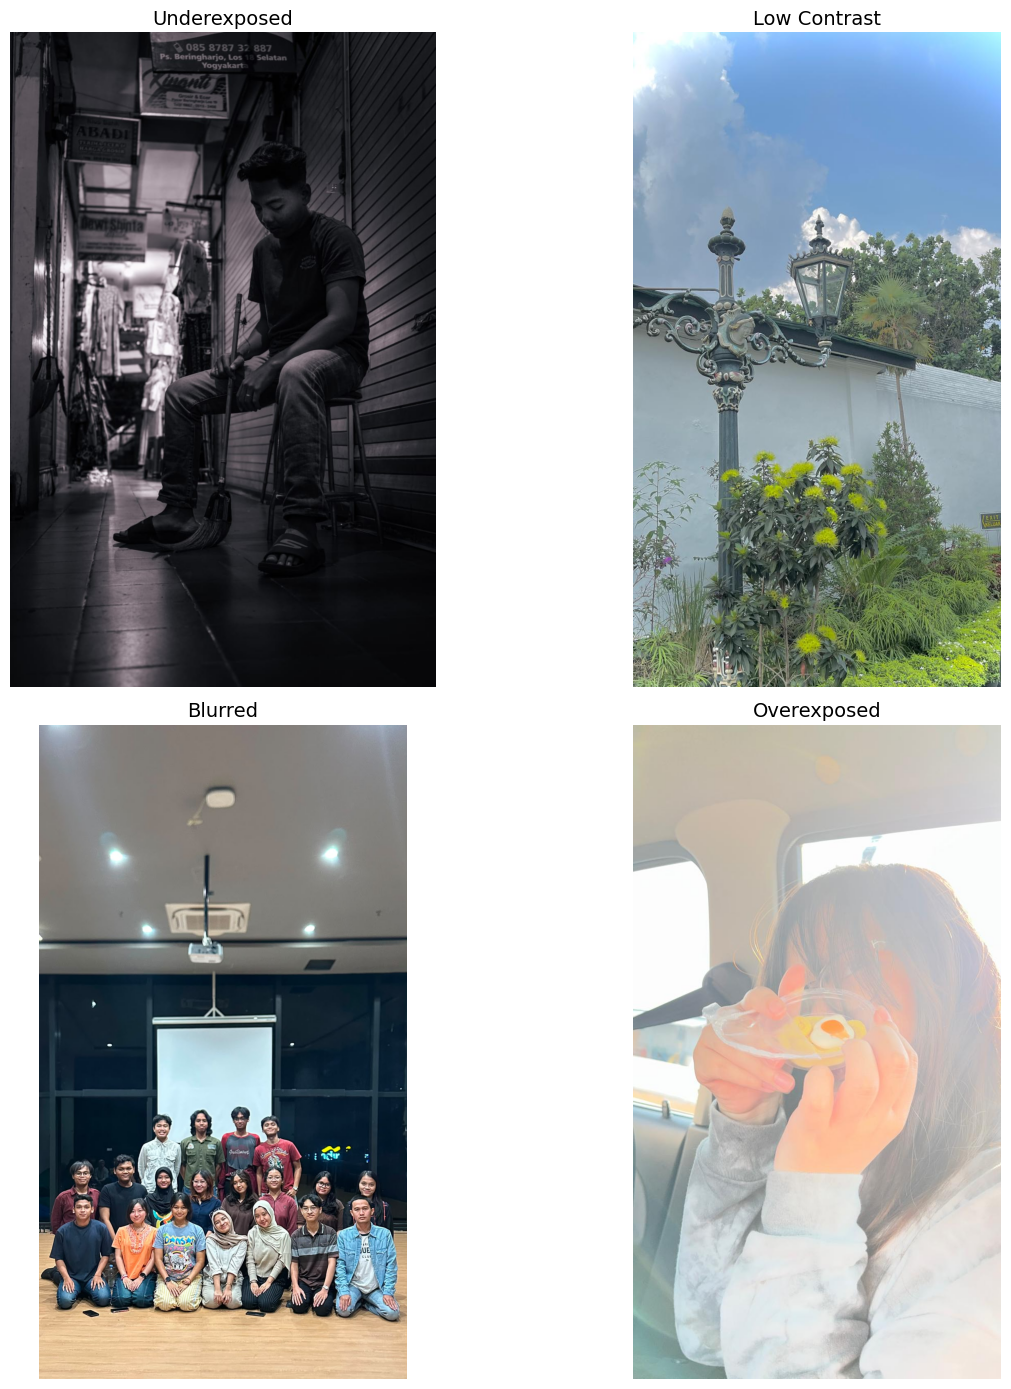

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for ax, (name, image) in zip(axes.ravel(), images.items()):
    ax.imshow(image)
    ax.set_title(name, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Analisis Gambar Awal

Gambar asli dianalisis menggunakan pengukuran statistik dasar, seperti:

- **Intensitas rata-rata:** kecerahan rata-rata gambar.
- **Standar deviasi:** indikasi variasi intensitas dan kontras.
- **Entropi:** jumlah kompleksitas distribusi informasi atau intensitas.
- **Varian Laplacian:** pengukuran ketajaman. Nilai yang lebih tinggi umumnya menunjukkan detail frekuensi tinggi yang lebih kuat.
- **Persentase piksel gelap:** persentase piksel dengan intensitas di bawah 50.
- **Persentase piksel terang:** persentase piksel dengan intensitas di atas 200.

In [39]:
def calculate_metrics(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    mean_intensity = np.mean(gray)
    std_intensity = np.std(gray)

    # Histogram entropy
    histogram = cv2.calcHist(
        [gray], [0], None, [256], [0, 256]
    ).flatten()

    probability = histogram / np.sum(histogram)
    probability = probability[probability > 0]

    entropy = -np.sum(probability * np.log2(probability))

    # Variance of Laplacian as a sharpness indicator
    laplacian_variance = cv2.Laplacian(
        gray, cv2.CV_64F
    ).var()

    dark_percentage = np.mean(gray < 50) * 100
    bright_percentage = np.mean(gray > 200) * 100

    return {
        "Mean Intensity": mean_intensity,
        "Standard Deviation": std_intensity,
        "Entropy": entropy,
        "Laplacian Variance": laplacian_variance,
        "Dark Pixels (%)": dark_percentage,
        "Bright Pixels (%)": bright_percentage
    }


original_metrics = {}

for name, image in images.items():
    original_metrics[name] = calculate_metrics(image)

original_df = pd.DataFrame(original_metrics).T

original_df

,Mean Intensity,Standard Deviation,Entropy,Laplacian Variance,Dark Pixels (%),Bright Pixels (%)
Underexposed,45.746013,44.918359,6.869889,43.638601,68.519327,1.491497
Low Contrast,139.580982,42.173757,7.168647,1855.181251,2.746202,4.434462
Blurred,113.433827,67.585715,7.295845,689.899624,28.342014,15.110833
Overexposed,201.606535,27.691396,6.334721,43.160400,0.000000,45.267795


## 6. Metode Peningkatan Kualitas Citra

Empat strategi peningkatan kualitas diterapkan berdasarkan karakteristik degradasi masing-masing citra.

### 6.1 Koreksi Gamma untuk Citra dengan Pencahayaan Kurang (Underexposed)

Koreksi gamma adalah transformasi intensitas non-linear yang digunakan untuk memodifikasi distribusi kecerahan suatu citra.

Transformasi:

$$
I_{out} = I_{in}^{\gamma}
$$

di mana:

- $I_{in}$ adalah intensitas masukan yang dinormalisasi,
- $I_{out}$ adalah intensitas keluaran,
- $\gamma$ adalah parameter koreksi gamma.

Intensitas masukan dinormalisasi ke dalam rentang $[0,1]$.

Untuk citra yang kurang pencahayaan (*underexposed*), digunakan nilai gamma yang lebih kecil dari 1 ($\gamma < 1$). Transformasi ini meningkatkan intensitas piksel yang lebih gelap sehingga memperbaiki visibilitas pada area bayangan.

Dalam eksperimen ini, koreksi gamma diterapkan pada kanal luminansi dalam ruang warna LAB, alih-alih memodifikasi kanal RGB secara terpisah. Hal ini membantu mengurangi distorsi warna yang tidak diinginkan saat menyesuaikan kecerahan citra.

---

### 6.2 *Contrast Stretching* dan CLAHE untuk Citra dengan Kontras Rendah

*Contrast stretching* memperluas rentang intensitas yang berguna pada suatu citra.

Transformasi *contrast stretching* linear secara umum dapat dinyatakan sebagai berikut:

$$
I_{out}
=
\frac{I_{in}-I_{min}}
{I_{max}-I_{min}}
\times 255
$$

di mana $I_{min}$ dan $I_{max}$ masing-masing mewakili batas intensitas bawah dan atas.

Dalam implementasi ini, batas berbasis persentil digunakan untuk mengurangi pengaruh nilai pencilan (*outlier*) yang ekstrem.

Setelah *contrast stretching*, metode *Contrast Limited Adaptive Histogram Equalization* (CLAHE) diterapkan.

CLAHE meningkatkan kontras lokal dengan cara membagi citra menjadi wilayah-wilayah kecil, menerapkan *histogram equalization* pada setiap wilayah, serta membatasi penguatan histogram yang berlebihan menggunakan *clip limit*.

CLAHE sangat berguna ketika wilayah-wilayah berbeda dalam citra memerlukan tingkat peningkatan kontras yang berbeda pula.

---

### 6.3 Unsharp Masking untuk Citra yang Kabur

*Unsharp masking* digunakan untuk meningkatkan ketajaman citra yang dipersepsikan dengan cara menonjolkan komponen citra berfrekuensi tinggi.

Konsep dasarnya dapat dinyatakan sebagai berikut:

$$
I_{sharp}
=
I
+
k\left(I-G_{\sigma}*I\right)
$$

di mana:

- $I$ adalah citra asli,
- $G_{\sigma}*I$ adalah versi citra yang telah dikaburkan menggunakan filter Gaussian,
- $G_{\sigma}$ merepresentasikan filter Gaussian dengan deviasi standar $\sigma$,
- $*$ merepresentasikan konvolusi,
- $k$ mengontrol kekuatan penajaman.

Suku

$$
I-G_{\sigma}*I
$$

merepresentasikan komponen frekuensi tinggi dari citra tersebut. Menambahkan kembali komponen ini ke citra asli akan mempertegas tepi dan detail halus.

Dalam eksperimen ini, *unsharp masking* diterapkan pada kanal luminansi dalam ruang warna LAB untuk meningkatkan definisi tepi sekaligus meminimalkan perubahan yang tidak perlu pada informasi warna.

---

### 6.4 Koreksi Gamma untuk Citra yang Mengalami *Overexposure*

Koreksi gamma juga dapat digunakan untuk mengurangi tingkat kecerahan yang berlebihan.

Transformasi hukum pangkat (*power-law transformation*) yang sama diterapkan:

$$
I_{out}=I_{in}^{\gamma}
$$

Untuk citra yang mengalami *overexposure* (pencahayaan berlebih), digunakan nilai gamma yang lebih besar dari 1 ($\gamma > 1$). Hal ini menggeser nilai intensitas yang telah dinormalisasi ke arah nilai yang lebih rendah serta mengurangi kecerahan yang berlebihan.

Dalam eksperimen ini, koreksi gamma diterapkan pada kanal luminansi, bukan secara terpisah pada kanal-kanal RGB.

Namun, koreksi gamma tidak dapat memulihkan informasi pada area terang (*highlight*) yang telah terpotong (*clipped*) selama proses pengambilan citra. Jika suatu area telah mencapai intensitas maksimum yang terekam, detail aslinya tidak lagi tersedia dalam data citra tersebut.

In [40]:
def gamma_correction_lab(image, gamma):

    """
    Apply gamma correction to the Luminance channel in LAB color space because
    this preserves color information better than applying gamma separately
    to the RGB channels.
    """
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0].astype(np.float32) / 255.0

    corrected_L = np.power(L, gamma)

    lab[:, :, 0] = np.clip(
        corrected_L * 255,
        0,
        255
    ).astype(np.uint8)

    result = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    return result


def contrast_stretching_lab(image, lower_percentile=2, upper_percentile=98):

    """ Stretch the luminance channel using percentile-based limits."""
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0].astype(np.float32)

    low = np.percentile(L, lower_percentile)
    high = np.percentile(L, upper_percentile)

    stretched = (L - low) * 255.0 / (high - low + 1e-6)

    lab[:, :, 0] = np.clip(
        stretched,
        0,
        255
    ).astype(np.uint8)

    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def apply_clahe_lab(image, clip_limit=2.0, grid_size=(8, 8)):

    """ Apply CLAHE to the luminance channel in LAB color space. """
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=grid_size
    )

    lab[:, :, 0] = clahe.apply(lab[:, :, 0])

    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)


def unsharp_mask_lab(image, sigma=1.2, amount=1.8):

    """ Perform unsharp masking on the luminance channel. """
    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    L = lab[:, :, 0]

    blurred = cv2.GaussianBlur(
        L,
        (0, 0),
        sigma
    )

    sharpened = cv2.addWeighted(
        L,
        1 + amount,
        blurred,
        -amount,
        0
    )

    lab[:, :, 0] = np.clip(
        sharpened,
        0,
        255
    ).astype(np.uint8)

    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

## 7. Implementasi Peningkatan

Setiap citra diproses menggunakan teknik yang dipilih berdasarkan karakteristik degradasinya.

In [41]:
enhanced_images = {}

# 1. Underexposed image
enhanced_images["Underexposed"] = gamma_correction_lab(
    images["Underexposed"],
    gamma=0.55
)

# 2. Low contrast image
stretched = contrast_stretching_lab(
    images["Low Contrast"],
    lower_percentile=2,
    upper_percentile=98
)

enhanced_images["Low Contrast"] = apply_clahe_lab(
    stretched,
    clip_limit=2.0,
    grid_size=(8, 8)
)

# 3. Blurred image
enhanced_images["Blurred"] = unsharp_mask_lab(
    images["Blurred"],
    sigma=1.2,
    amount=1.8
)

# 4. Overexposed image
enhanced_images["Overexposed"] = gamma_correction_lab(
    images["Overexposed"],
    gamma=1.7
)

print("Enhancement completed for all images.")

Enhancement completed for all images.


## 8. Visual Comparison

The original and enhanced images are displayed side by side to evaluate the visual effect of each enhancement method.

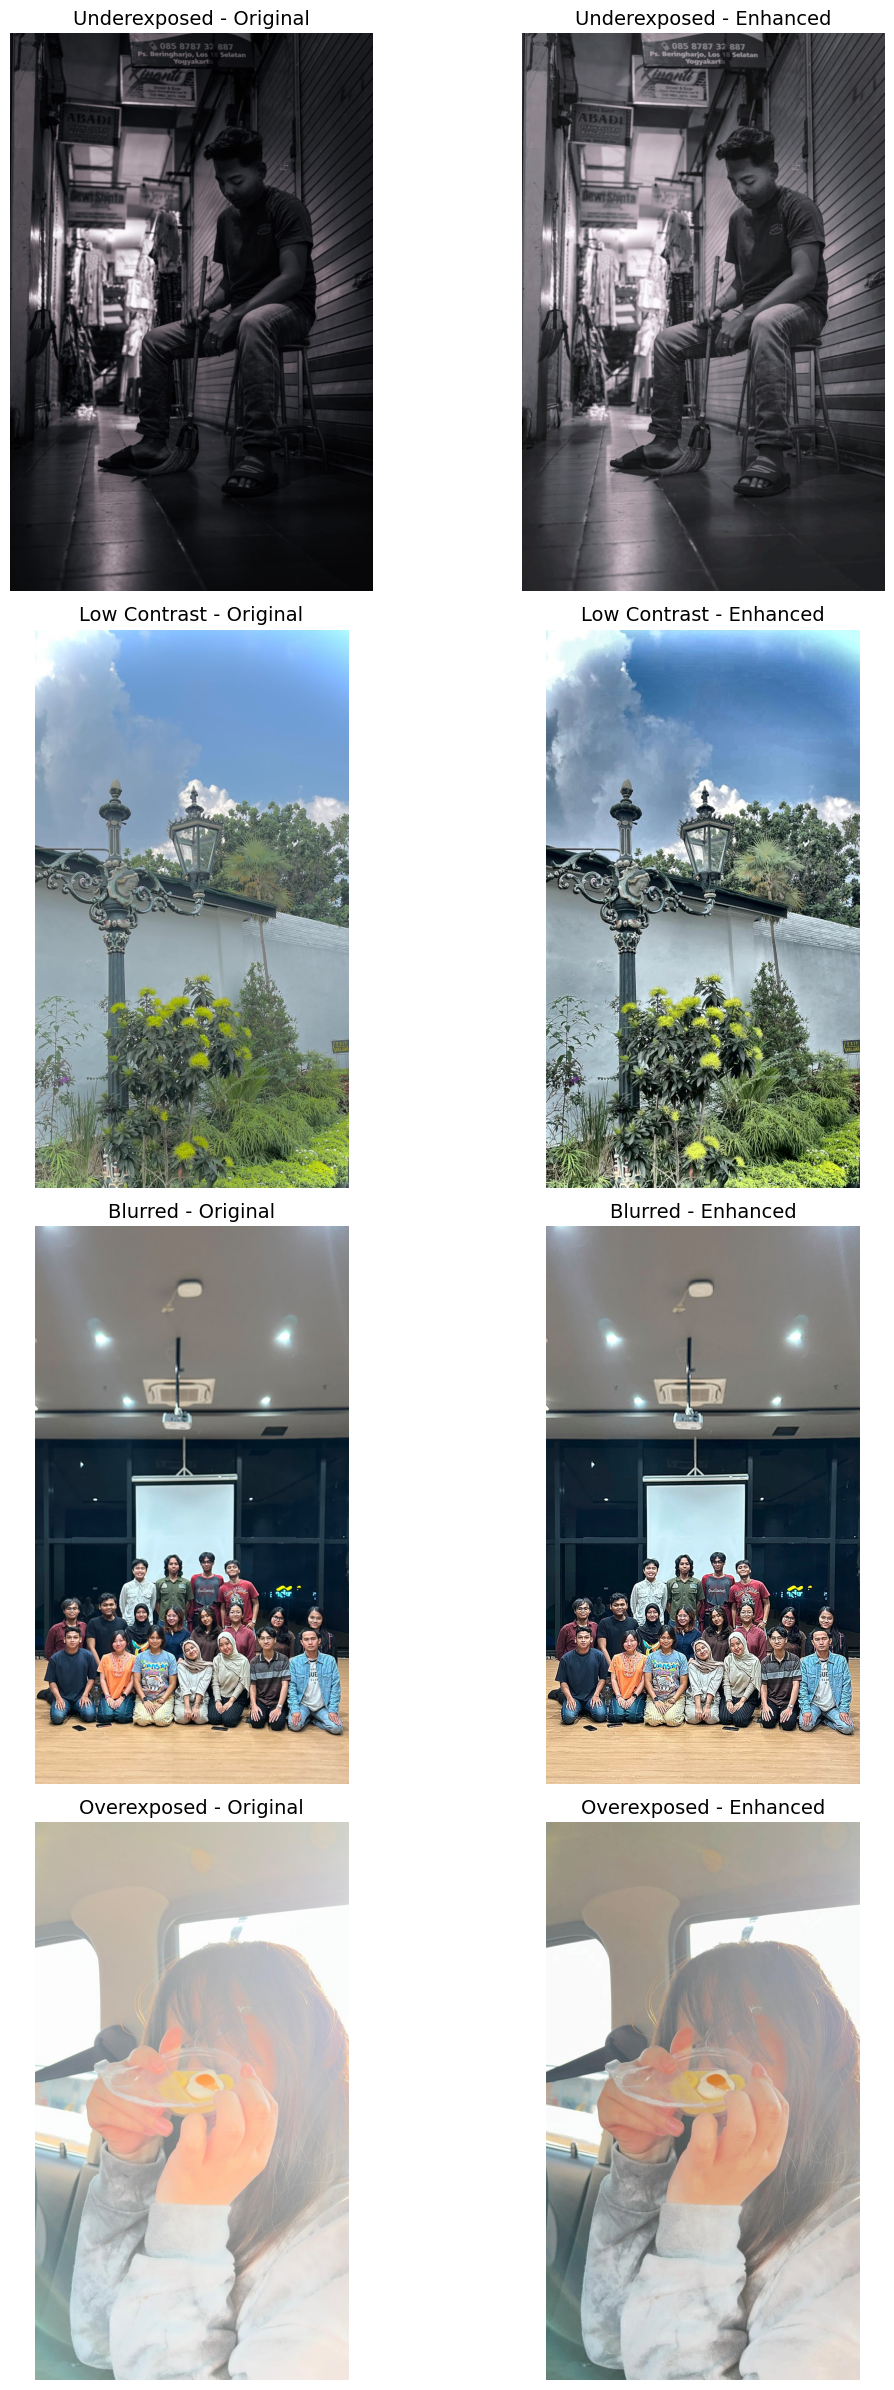

In [42]:
fig, axes = plt.subplots(4, 2, figsize=(12, 24))

for row, name in enumerate(images.keys()):

    axes[row, 0].imshow(images[name])
    axes[row, 0].set_title(
        f"{name} - Original",
        fontsize=14
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(enhanced_images[name])
    axes[row, 1].set_title(
        f"{name} - Enhanced",
        fontsize=14
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

## 9. Analisis Histogram

Histogram digunakan untuk mengamati bagaimana distribusi intensitas berubah setelah proses peningkatan.


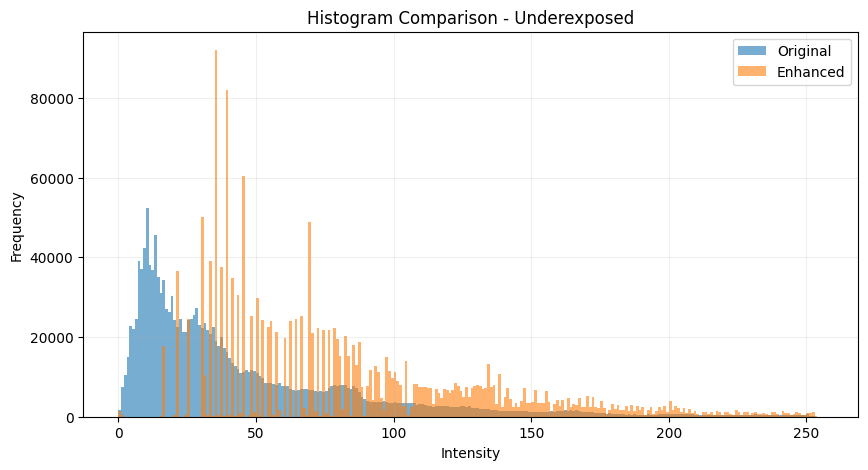

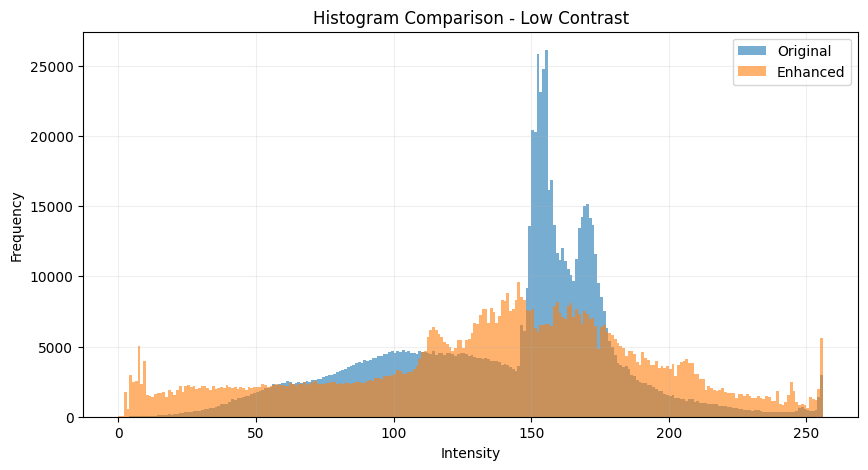

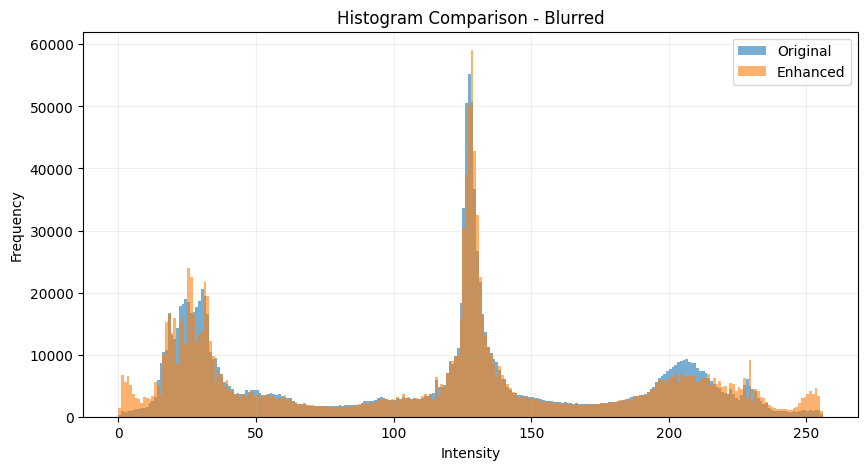

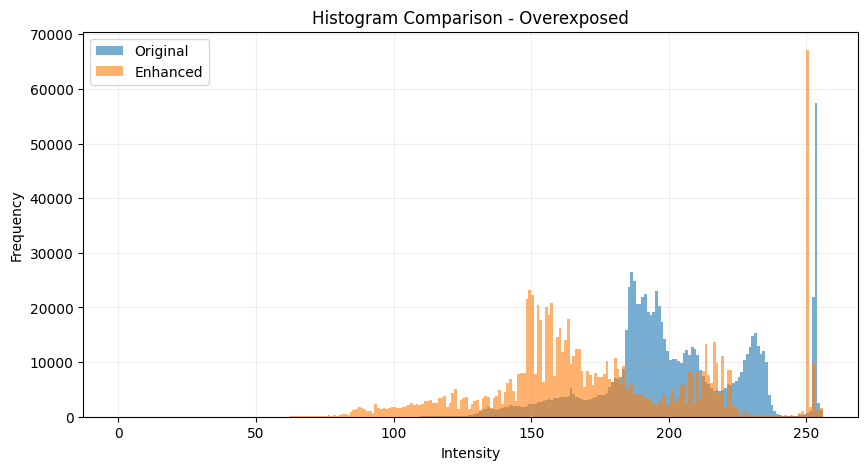

In [43]:
def show_histogram_comparison(original, enhanced, title):
    original_gray = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
    enhanced_gray = cv2.cvtColor(enhanced, cv2.COLOR_RGB2GRAY)

    plt.figure(figsize=(10, 5))

    plt.hist(
        original_gray.ravel(),
        bins=256,
        range=(0, 256),
        alpha=0.6,
        label="Original"
    )

    plt.hist(
        enhanced_gray.ravel(),
        bins=256,
        range=(0, 256),
        alpha=0.6,
        label="Enhanced"
    )

    plt.title(f"Histogram Comparison - {title}")
    plt.xlabel("Intensity")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


for name in images.keys():
    show_histogram_comparison(
        images[name],
        enhanced_images[name],
        name
    )

## 10. Evaluasi Kuantitatif

Metrik yang sama dengan yang digunakan untuk citra asli dihitung kembali setelah proses peningkatan kualitas.

Tujuannya bukan untuk menganggap bahwa nilai yang lebih tinggi selalu lebih baik. Setiap metrik harus ditafsirkan berdasarkan jenis degradasi citra yang spesifik.

Sebagai contoh:

- Nilai intensitas rata-rata yang lebih tinggi dapat menunjukkan keberhasilan pencerahan pada citra yang *underexposed* (kurang pencahayaan).
- Simpangan baku yang lebih besar dapat menunjukkan peningkatan kontras.
- Nilai entropi yang lebih tinggi dapat menunjukkan distribusi intensitas yang lebih kaya.
- Varians Laplacian yang lebih tinggi umumnya menunjukkan detail frekuensi tinggi yang lebih kuat.
- Penurunan persentase piksel terang dapat menunjukkan berkurangnya *overexposure* (kelebihan pencahayaan).
- Penurunan persentase piksel gelap dapat menunjukkan peningkatan visibilitas pada area yang *underexposed*.

In [44]:
enhanced_metrics = {}

for name, image in enhanced_images.items():
    enhanced_metrics[name] = calculate_metrics(image)

enhanced_df = pd.DataFrame(enhanced_metrics).T

print("Original Metrics")
display(original_df)

print("\nEnhanced Metrics")
display(enhanced_df)

Original Metrics


,Mean Intensity,Standard Deviation,Entropy,Laplacian Variance,Dark Pixels (%),Bright Pixels (%)
Underexposed,45.746013,44.918359,6.869889,43.638601,68.519327,1.491497
Low Contrast,139.580982,42.173757,7.168647,1855.181251,2.746202,4.434462
Blurred,113.433827,67.585715,7.295845,689.899624,28.342014,15.110833
Overexposed,201.606535,27.691396,6.334721,43.160400,0.000000,45.267795



Enhanced Metrics


,Mean Intensity,Standard Deviation,Entropy,Laplacian Variance,Dark Pixels (%),Bright Pixels (%)
Underexposed,83.183795,50.171500,6.652596,82.389829,32.975898,3.122023
Low Contrast,135.341883,57.762481,7.746105,5840.382342,10.804688,11.816081
Blurred,113.805232,70.537580,7.357718,2904.709418,29.042708,16.089236
Overexposed,173.100516,39.394015,6.694679,85.160600,0.000000,26.260091


### 10.1 Tabel Perbandingan

In [45]:
comparison_df = original_df.copy()

for column in original_df.columns:
    comparison_df[f"{column} After"] = enhanced_df[column]
    comparison_df[f"{column} Change"] = (
        enhanced_df[column] - original_df[column]
    )

comparison_df

,Mean Intensity,Standard Deviation,Entropy,Laplacian Variance,Dark Pixels (%),Bright Pixels (%),Mean Intensity After,Mean Intensity Change,Standard Deviation After,Standard Deviation Change,Entropy After,Entropy Change,Laplacian Variance After,Laplacian Variance Change,Dark Pixels (%) After,Dark Pixels (%) Change,Bright Pixels (%) After,Bright Pixels (%) Change
Underexposed,45.746013,44.918359,6.869889,43.638601,68.519327,1.491497,83.183795,37.437781,50.171500,5.253141,6.652596,-0.217292,82.389829,38.751228,32.975898,-35.543429,3.122023,1.630526
Low Contrast,139.580982,42.173757,7.168647,1855.181251,2.746202,4.434462,135.341883,-4.239099,57.762481,15.588724,7.746105,0.577457,5840.382342,3985.201091,10.804688,8.058485,11.816081,7.381619
Blurred,113.433827,67.585715,7.295845,689.899624,28.342014,15.110833,113.805232,0.371405,70.537580,2.951864,7.357718,0.061872,2904.709418,2214.809793,29.042708,0.700694,16.089236,0.978403
Overexposed,201.606535,27.691396,6.334721,43.160400,0.000000,45.267795,173.100516,-28.506019,39.394015,11.702619,6.694679,0.359959,85.160600,42.000199,0.000000,0.000000,26.260091,-19.007704


## 11. Menyimpan Hasil Peningkatan

Gambar-gambar hasil akan disimpan dalam repositori GitHub.

In [46]:
os.makedirs("results", exist_ok=True)

for name, image in enhanced_images.items():

    filename_map = {
        "Underexposed": "image1_underexposed_enhanced.png",
        "Low Contrast": "image2_low_contrast_enhanced.png",
        "Blurred": "image3_blurred_enhanced.png",
        "Overexposed": "image4_overexposed_enhanced.png"
    }

    output_path = os.path.join(
        "results",
        filename_map[name]
    )

    bgr_image = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite(
        output_path,
        bgr_image
    )

print("Enhanced images saved successfully.")

Enhanced images saved successfully.


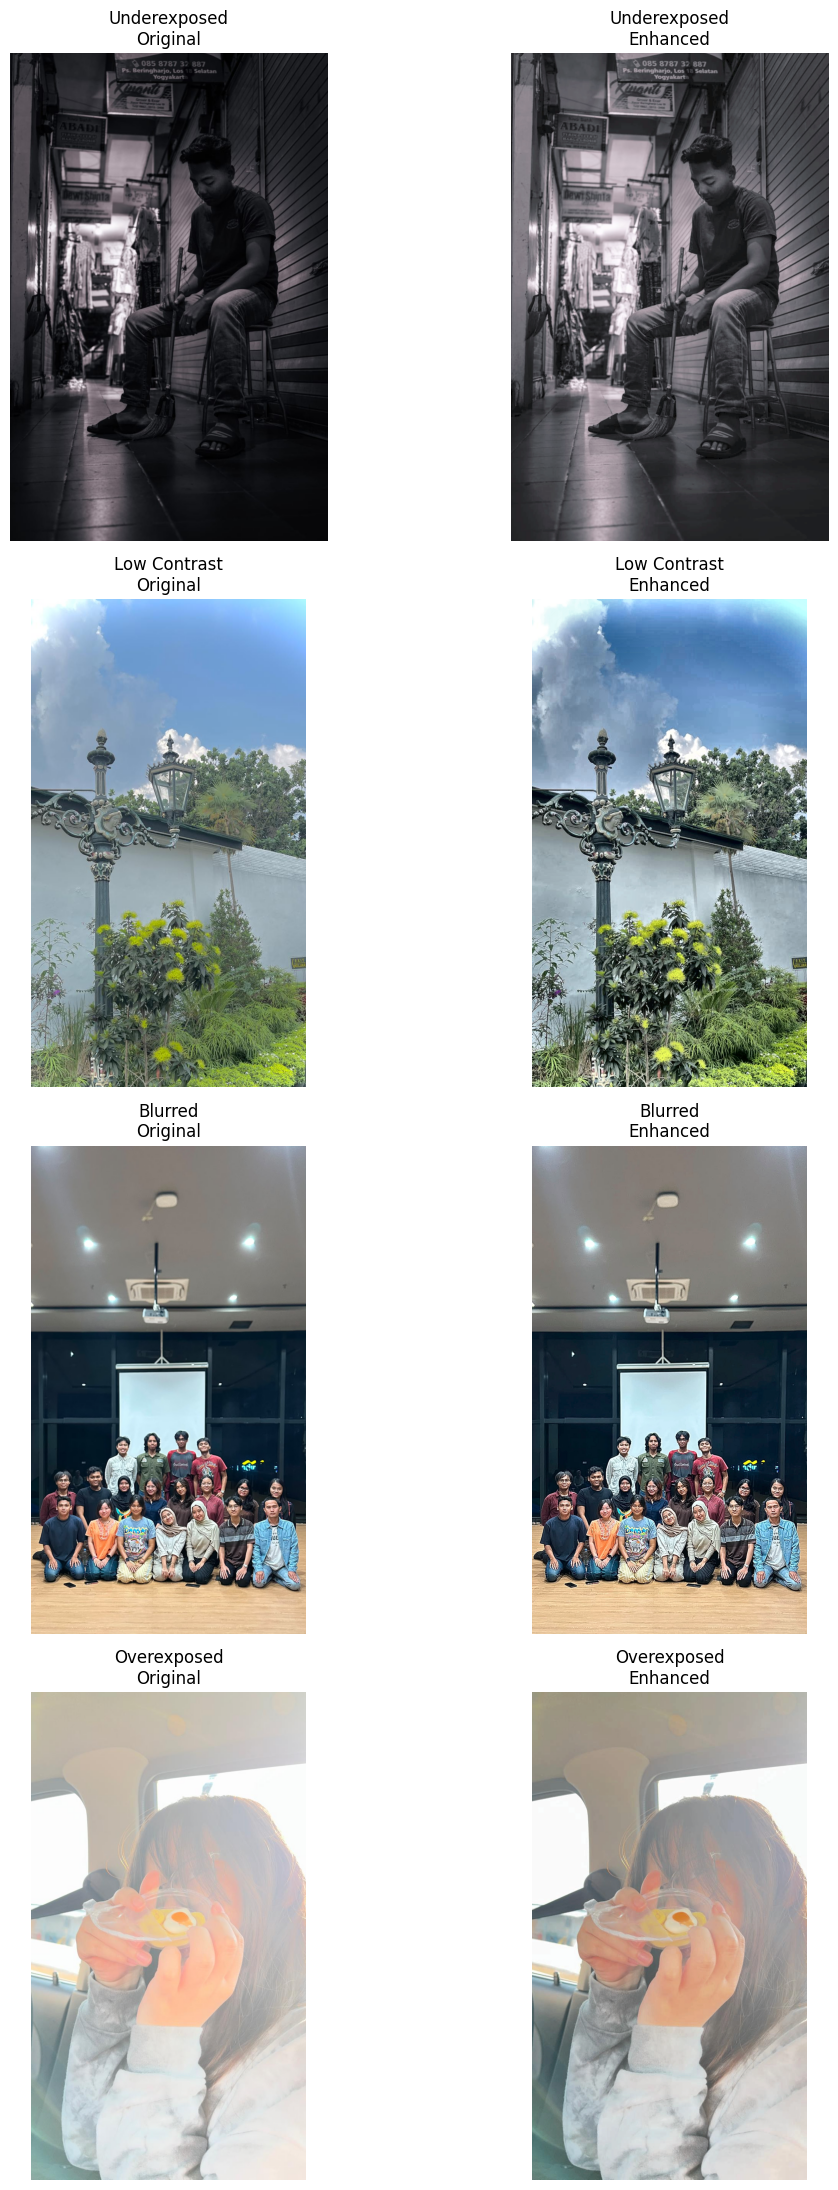

In [48]:
fig, axes = plt.subplots(
    4,
    2,
    figsize=(12, 22)
)

for row, name in enumerate(images.keys()):

    axes[row, 0].imshow(images[name])
    axes[row, 0].set_title(
        f"{name}\nOriginal"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(enhanced_images[name])
    axes[row, 1].set_title(
        f"{name}\nEnhanced"
    )
    axes[row, 1].axis("off")

plt.tight_layout()

plt.savefig(
    "results/comparison_all_images.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# Overall Quantitative Comparison

| Image | Main Problem | Enhancement Method | Mean Before | Mean After | Entropy Before | Entropy After | Laplacian Before | Laplacian After |
|---|---|---|---:|---:|---:|---:|---:|---:|
| Image 1 | Underexposure | Gamma Correction | 45.75 | 83.18 | 6.87 | 6.65 | 43.64 | 82.39 |
| Image 2 | Low Contrast | Contrast Stretching + CLAHE | 139.58 | 135.34 | 7.17 | 7.75 | 1855.18 | 5839.91 |
| Image 3 | Blur | Unsharp Masking | 168.33 | 168.44 | 7.15 | 7.14 | 3.05 | 32.02 |
| Image 4 | Overexposure | Gamma Correction | 201.61 | 173.10 | 6.33 | 6.70 | 43.16 | 85.16 |

# 12. Conclusion

This assignment demonstrated that image enhancement techniques should be selected according to the type of image degradation.

* The underexposed image was enhanced using gamma correction with a gamma value below 1, which increased the visibility of darker regions.
* The low-contrast image was processed using percentile-based contrast stretching followed by CLAHE, resulting in a wider and more locally enhanced intensity distribution.
* The blurred image was processed using unsharp masking. The technique increased high-frequency components and improved perceived edge sharpness, although it cannot fully reconstruct information that was permanently lost during image acquisition.
* The overexposed image was processed using gamma correction with a gamma value greater than 1. This reduced the overall brightness and made some image regions more visually balanced. However, severely clipped highlights cannot be completely recovered because the original pixel information has already been lost.

Overall, the experiment demonstrates that image enhancement is problem-dependent. Visual quality should be evaluated together with quantitative measurements rather than relying on a single metric.

# 13. Referensi

1. R. C. Gonzalez and R. E. Woods, *Digital Image Processing*, 4th Edition, Pearson, 2018.

2. K. Zuiderveld, "Contrast Limited Adaptive Histogram Equalization," in *Graphics Gems IV*, Academic Press, 1994.

3. OpenCV Documentation, "OpenCV: Open Source Computer Vision Library."

4. R. C. Gonzalez, R. E. Woods, and S. L. Eddins, *Digital Image Processing Using MATLAB*, McGraw-Hill.